# Assignment 17 - Text Cleaning, Preprocessing & NLP Pipeline

## Name
Suryansh Tiwari

## Dataset Used

**SMS Spam Collection Dataset**

Kaggle Link:
https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

### Objective

The objective of this assignment is to understand how raw text data is cleaned and preprocessed before it can be used for Natural Language Processing (NLP) tasks.

In this assignment, I will perform:
- Basic text cleaning
- Advanced text cleaning
- Stopword removal
- Tokenization
- Stemming
- Lemmatization
- Build a complete NLP preprocessing pipeline

Before applying these preprocessing techniques, I will first explore the dataset to understand the quality of the raw text.

In [1]:
import pandas as pd
import numpy as np

import re
import string

import nltk

import matplotlib.pyplot as plt
import seaborn as sns

# NLTK resources
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

In [3]:
df=pd.read_csv('spam.csv',encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 677.1 KB


In [6]:
df.shape

(5572, 5)

In [7]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')

In [8]:
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [9]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4057,ham,Hi di is yijue we're meeting at 7 pm at esapla...,NaN,NaN,NaN
5396,ham,As in i want custom officer discount oh.,NaN,NaN,NaN
607,ham,what I meant to say is cant wait to see u agai...,NaN,NaN,NaN
2709,ham,Sorry de i went to shop.,NaN,NaN,NaN
3302,ham,"It'll be tough, but I'll do what I have to",NaN,NaN,NaN


In [10]:
df.describe(include='all')

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


# Dataset Exploration

Before starting the NLP preprocessing pipeline, I first explored the dataset to understand its structure.

### Initial observations

- The dataset contains **5572 SMS messages**.
- It has **5 columns**, but only the first two are useful.
- `v1` contains the message label (ham or spam).
- `v2` contains the SMS text.
- The remaining columns (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) contain mostly missing values and do not contribute any useful information.

Since these extra columns are almost empty, I will remove them before beginning text preprocessing.

In [11]:
df=df[["v1","v2"]]

df.columns=["label","text"]


df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   5572 non-null   str  
 1   text    5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [13]:
df["label"].value_counts()

label
ham     4825
spam     747
Name: count, dtype: int64

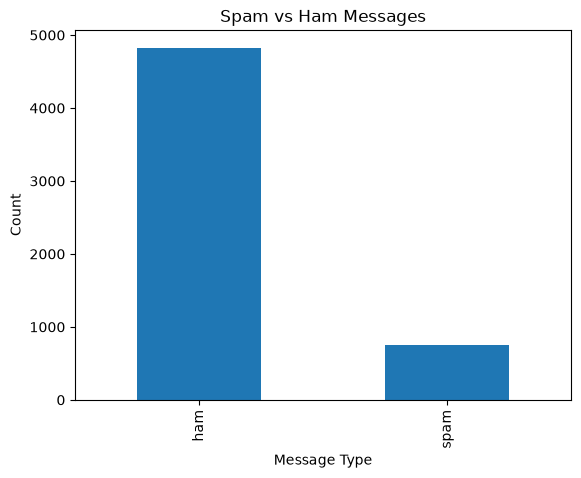

In [14]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

In [15]:
df['text_length'] = df['text'].apply(len)
df['text_length'].describe()

count    5572.000000
mean       80.118808
std        59.690841
min         2.000000
25%        36.000000
50%        61.000000
75%       121.000000
max       910.000000
Name: text_length, dtype: float64

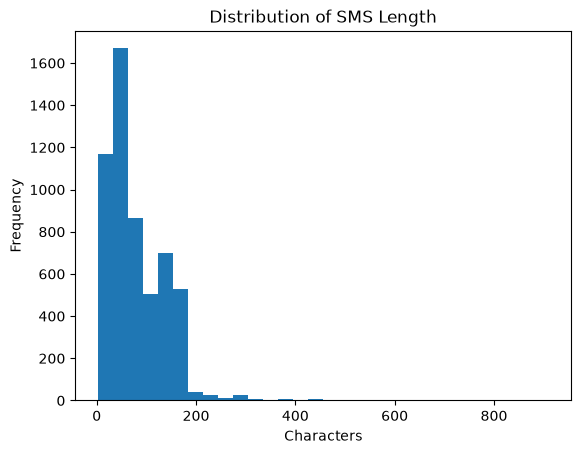

In [16]:
plt.hist(df["text_length"], bins=30)

plt.title("Distribution of SMS Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [17]:
df.sort_values("text_length", ascending=False).head(10)

,label,text,text_length
1084,ham,For me the love should start with attraction.i...,910
1862,ham,The last thing i ever wanted to do was hurt yo...,790
2433,ham,Indians r poor but India is not a poor country...,632
1578,ham,How to Make a girl Happy? It's not at all diff...,611
2847,ham,Sad story of a Man - Last week was my b'day. M...,588
2157,ham,Sad story of a Man - Last week was my b'day. M...,588
2379,ham,"Good evening Sir, hope you are having a nice d...",482
3015,ham,"&lt;#&gt; is fast approaching. So, Wish u a v...",461
1512,ham,"Hey sweet, I was wondering when you had a mome...",458
5104,ham,A Boy loved a gal. He propsd bt she didnt mind...,450


## Observations after Initial Exploration

After exploring the dataset, I noticed a few important points before starting the cleaning process.

- The original dataset contained five columns, but only `label` and `text` were useful. The remaining columns contained mostly missing values and were removed.
- The dataset has **5572 SMS messages**.
- There are **4825 ham messages** and **747 spam messages**, so the dataset is clearly imbalanced.
- Most SMS messages are relatively short, although a few messages are much longer (up to 910 characters).
- Since this assignment focuses on text preprocessing rather than model training, the class imbalance is not an issue at this stage, but it is something to keep in mind for future NLP models.

## Part-1

## Task-1

In [18]:
for i in range(5):
    print(f"Message {i+1}")
    print("Label :", df.loc[i, "label"])
    print("Text  :", df.loc[i, "text"])
    print("-"*80)

Message 1
Label : ham
Text  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
--------------------------------------------------------------------------------
Message 2
Label : ham
Text  : Ok lar... Joking wif u oni...
--------------------------------------------------------------------------------
Message 3
Label : spam
Text  : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
--------------------------------------------------------------------------------
Message 4
Label : ham
Text  : U dun say so early hor... U c already then say...
--------------------------------------------------------------------------------
Message 5
Label : ham
Text  : Nah I don't think he goes to usf, he lives around here though
--------------------------------------------------------------------------------


In [19]:
uppercase_messages = df[df['text'].str.contains(r"\b[A-Z]{2,}\b", regex=True)]
print("Messages containing uppercase words:", len(uppercase_messages))
uppercase_messages[['label', 'text']].head()

Messages containing uppercase words: 931


,label,text
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...
11,spam,"SIX chances to win CASH! From 100 to 20,000 po..."
12,spam,URGENT! You have won a 1 week FREE membership ...


In [20]:
number_messages=df[df["text"].str.contains(r"\d", regex=True)]
print("Messages containing numbers:", len(number_messages))
number_messages[['label', 'text']].head()

Messages containing numbers: 1456


,label,text
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
5,spam,FreeMsg Hey there darling it's been 3 week's n...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [21]:
punctuation_messages=df[df["text"].str.contains(r"[^\w\s]", regex=True)]
print("Messages containing punctuation:", len(punctuation_messages))
punctuation_messages[['label', 'text']].head()

Messages containing punctuation: 5113


,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
extra_space_messages=df[df["text"].str.contains(r"\s{2,}", regex=True)]
print("Messages containing extra spaces:", len(extra_space_messages))
extra_space_messages[['label', 'text']].head()

Messages containing extra spaces: 260


,label,text
44,ham,Great! I hope you like your man well endowed. ...
51,ham,"A gram usually runs like &lt;#&gt; , a half e..."
55,ham,Do you know what Mallika Sherawat did yesterda...
78,ham,Does not operate after &lt;#&gt; or what
177,ham,Turns out my friends are staying for the whole...


In [23]:
url_messages=df[df["text"].str.contains(r"http|www", case=False, regex=True)]
print("Messages containing URLs:", len(url_messages))
url_messages[['label', 'text']].head()

Messages containing URLs: 110


,label,text
12,spam,URGENT! You have won a 1 week FREE membership ...
15,spam,"XXXMobileMovieClub: To use your credit, click ..."
163,spam,-PLS STOP bootydelious (32/F) is inviting you ...
190,spam,Are you unique enough? Find out from 30th Augu...
224,spam,"500 New Mobiles from 2004, MUST GO! Txt: NOKIA..."


In [24]:
email_messages=df[df["text"].str.contains(r"\S+@\S+", regex=True)]
print("Messages containing email addresses:", len(email_messages))
email_messages[['label', 'text']].head()

Messages containing email addresses: 20


,label,text
134,spam,Want 2 get laid tonight? Want real Dogging loc...
135,ham,I only haf msn. It's yijue@hotmail.com
234,spam,Text & meet someone sexy today. U can find a d...
473,spam,Want 2 get laid tonight? Want real Dogging loc...
540,spam,from www.Applausestore.com MonthlySubscription...


## Observations from the Raw SMS Data

Before applying any preprocessing, I explored the raw messages to understand what kinds of cleaning would actually be required.

### Findings

- **931 messages** contain fully uppercase words (such as promotional words like "FREE", "WIN", "URGENT", etc.).
- **1456 messages** contain numerical values such as phone numbers, prices, dates or OTP-like values.
- **5113 messages** contain punctuation marks, making punctuation removal one of the most important preprocessing steps.
- **260 messages** contain multiple consecutive spaces that should be normalized.
- **110 messages** contain URLs that are not useful for most NLP classification tasks.
- **20 messages** contain email addresses. Although this is a small portion of the dataset, removing them helps create cleaner text.

Based on these observations, the next step is to perform basic text cleaning followed by advanced cleaning techniques.

# Task-2

In [25]:
df['lower_text']=df["text"].str.lower()
df[['text','lower_text']].head()

,text,lower_text
0,"Go until jurong point, crazy.. Available only ...","go until jurong point, crazy.. available only ..."
1,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,"Nah I don't think he goes to usf, he lives aro...","nah i don't think he goes to usf, he lives aro..."


In [26]:
import re

def remove_punctuation(text):
    return re.sub(r'[^\w\s]', '', text)

df['no_punctuation'] = df['lower_text'].apply(remove_punctuation)
df[['lower_text','no_punctuation']].head()

,lower_text,no_punctuation
0,"go until jurong point, crazy.. available only ...",go until jurong point crazy available only in ...
1,ok lar... joking wif u oni...,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...,free entry in 2 a wkly comp to win fa cup fina...
3,u dun say so early hor... u c already then say...,u dun say so early hor u c already then say
4,"nah i don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [27]:
def remove_numbers(text):
    return re.sub(r'\d+', '', text)

df['no_numbers'] = df['no_punctuation'].apply(remove_numbers)
df[['no_punctuation','no_numbers']].head()

,no_punctuation,no_numbers
0,go until jurong point crazy available only in ...,go until jurong point crazy available only in ...
1,ok lar joking wif u oni,ok lar joking wif u oni
2,free entry in 2 a wkly comp to win fa cup fina...,free entry in a wkly comp to win fa cup final...
3,u dun say so early hor u c already then say,u dun say so early hor u c already then say
4,nah i dont think he goes to usf he lives aroun...,nah i dont think he goes to usf he lives aroun...


In [28]:
def remove_extra_spaces(text):
    return re.sub(r'\s{2,}', ' ', text).strip()
df['clean_text_basic']=df['no_numbers'].apply(remove_extra_spaces)
df[['text','clean_text_basic']].head()

,text,clean_text_basic
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


## Observations after Basic Cleaning

After applying the basic cleaning steps, I compared the original messages with the cleaned version.

Some changes I noticed were:

- All text has been converted to lowercase, making the text more consistent.
- Punctuation marks such as commas, periods and apostrophes have been removed.
- Numerical values have been removed from the messages.
- Multiple spaces have been replaced with a single space.
- The meaning of the messages is still preserved even though unnecessary characters have been removed.

At this stage, the text is cleaner than the raw dataset, but it still contains URLs, email addresses, stopwords and other noisy patterns. These will be handled in the next task.

## Part-2

## Task-3

In [30]:
def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text)
df["no_urls"] = df['clean_text_basic'].apply(remove_urls)

In [31]:
def remove_emails(text):
    return re.sub(r'\S+@\S+', '', text)
df['no_emails'] = df['no_urls'].apply(remove_emails)

In [36]:
html_messages = df[df["clean_text_basic"].str.contains(r"<.*?>", regex=True)]

print("Messages containing HTML:", len(html_messages))

Messages containing HTML: 0


In [32]:
def remove_html(text):
    return re.sub(r"<.*?>", '', text)
df['no_html'] = df['no_emails'].apply(remove_html)

I checked whether the dataset contained HTML tags before removing them. No HTML content was found, but I still included the cleaning function because it is a common preprocessing step in NLP pipelines.

In [33]:
def remove_special_characters(text):
    return re.sub(r'[^a-zA-Z\s]', '', text)
df['clean_text_advanced'] = df['no_html'].apply(remove_special_characters)

In [34]:
df[['text','clean_text_advanced']].sample(8)

,text,clean_text_advanced
2359,Spook up your mob with a Halloween collection ...,spook up your mob with a halloween collection ...
729,Dunno y u ask me.,dunno y u ask me
3252,K:)k..its good:)when are you going?,kkits goodwhen are you going
2535,Can you pls pls send me a mail on all you know...,can you pls pls send me a mail on all you know...
5265,Gud ni8.swt drms.take care,gud niswt drmstake care
2544,She is our sister.. She belongs 2 our family.....,she is our sister she belongs our family she i...
1792,WIN: We have a winner! Mr. T. Foley won an iPo...,win we have a winner mr t foley won an ipod mo...
3361,No messages on her phone. I'm holding it now,no messages on her phone im holding it now


## Observations after Advanced Cleaning

After applying the advanced cleaning steps, I compared the text again.

Some observations were:

- URLs and email addresses were successfully removed whenever they appeared.
- I checked the dataset for HTML tags before cleaning and found that no messages contained HTML content.
- Special characters and symbols were removed from the text.
- I also noticed that removing punctuation can sometimes join two words together. For example, "good:)when" becomes "goodwhen". This is a limitation of the current cleaning approach and could be improved by replacing punctuation with spaces instead of removing it completely.
- Overall, the messages are now much cleaner and ready for NLP preprocessing.

## Task-4

In [37]:
import nltk

In [38]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
print("Number of stop words:", len(stop_words))
print(list(stop_words)[:10])

Number of stop words: 198
["i've", 'shouldn', "they'll", 'he', 'couldn', 'in', "shan't", 'hers', 've', "she'll"]


In [40]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = []
    for word in words:
        if word not in stop_words:
            filtered_words.append(word)
    return ' '.join(filtered_words)

In [41]:
df["text_no_stopwords"] = df['clean_text_advanced'].apply(remove_stopwords)
df[['clean_text_advanced','text_no_stopwords']].head()

,clean_text_advanced,text_no_stopwords
0,go until jurong point crazy available only in ...,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni,ok lar joking wif u oni
2,free entry in a wkly comp to win fa cup final ...,free entry wkly comp win fa cup final tkts st ...
3,u dun say so early hor u c already then say,u dun say early hor u c already say
4,nah i dont think he goes to usf he lives aroun...,nah dont think goes usf lives around though


In [43]:
df[['text','clean_text_advanced','text_no_stopwords']].sample(8)

,text,clean_text_advanced,text_no_stopwords
4757,URGENT! Your Mobile number has been awarded wi...,urgent your mobile number has been awarded wit...,urgent mobile number awarded prize guaranteed ...
4460,Thanks again for your reply today. When is ur ...,thanks again for your reply today when is ur v...,thanks reply today ur visa coming r u still bu...
3012,FREE UNLIMITED HARDCORE PORN direct 2 your mob...,free unlimited hardcore porn direct your mobil...,free unlimited hardcore porn direct mobile txt...
3423,Am new 2 club & dont fink we met yet Will B gr...,am new club dont fink we met yet will b gr c u...,new club dont fink met yet b gr c u please lea...
5079,\Keep ur problems in ur heart,keep ur problems in ur heart,keep ur problems ur heart
1453,Stupid.its not possible,stupidits not possible,stupidits possible
4009,Wan2 win a Meet+Greet with Westlife 4 U or a m...,wan win a meetgreet with westlife u or a m the...,wan win meetgreet westlife u currently tour un...
4289,"For you information, IKEA is spelled with all ...",for you information ikea is spelled with all c...,information ikea spelled caps yelling thought ...


## Task-5

In [45]:
def remove_repeated_characters(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

examples = ["goooood","pleeease","sooooo happy"]

for word in examples:
    print("Before:", word)
    print("After :", remove_repeated_characters(word))
    print("-" * 30)

Before: goooood
After : good
------------------------------
Before: pleeease
After : pleease
------------------------------
Before: sooooo happy
After : soo happy
------------------------------


In [46]:
df["normalized_text"] = df["text_no_stopwords"].apply(remove_repeated_characters)

In [47]:
common_slang = [
    "u", "ur", "pls", "msg", "luv",
    "thx", "thanx", "tmr", "gr8",
    "wat", "wif", "gud", "nite", "coz", "c"
]

for word in common_slang:
    count = df["normalized_text"].str.split().apply(lambda x: word in x).sum()

    if count > 0:
        print(f"{word} : {count}")

u : 808
ur : 306
pls : 98
msg : 78
luv : 29
thx : 2
thanx : 31
tmr : 27
wat : 92
wif : 26
gud : 50
nite : 30
coz : 19
c : 81


In [51]:
slang_dict = {
    "u": "you",
    "ur": "your",
    "pls": "please",
    "msg": "message",
    "luv": "love",
    "thx": "thanks",
    "thanx": "thanks",
    "tmr": "tomorrow",
    "gr8": "great",
    "wat": "what",
    "wif": "with",
    "gud": "good",
    "nite": "night",
    "coz": "because",
    "c": "see",
    "txt": "text",
    "wk": "week",
    "wkly": "weekly",
    "mins": "minutes",
    "ya": "yeah",
    "yae": "yeah",
    "lor": "lord",
    "da": "the",
    "oso": "also"
}

In [52]:
def replace_slang(text):
    words = text.split()
    updated_words = []
    for word in words:
        if word in slang_dict:
            updated_words.append(slang_dict[word])
        else:
            updated_words.append(word)
    return " ".join(updated_words)

In [53]:
df['clean_text'] = df['normalized_text'].apply(replace_slang)
df[["normalized_text", "clean_text"]].head(10)

,normalized_text,clean_text
0,go jurong point crazy available bugis n great ...,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni,ok lar joking with you oni
2,free entry wkly comp win fa cup final tkts st ...,free entry weekly comp win fa cup final tkts s...
3,u dun say early hor u c already say,you dun say early hor you see already say
4,nah dont think goes usf lives around though,nah dont think goes usf lives around though
5,freemsg hey darling weeks word back id like fu...,freemsg hey darling weeks word back id like fu...
6,even brother like speak treat like aids patent,even brother like speak treat like aids patent
7,per request melle melle oru minnaminunginte nu...,per request melle melle oru minnaminunginte nu...
8,winner valued network customer selected receiv...,winner valued network customer selected receiv...
9,mobile months u r entitled update latest colou...,mobile months you r entitled update latest col...


## Observations after Slang Replacement

Before creating the slang dictionary, I checked which abbreviations were actually present in the dataset.

Some of the most frequently occurring abbreviations were:

| Slang | Count |
|--------|------:|
| u | 808 |
| ur | 306 |
| pls | 98 |
| wat | 92 |
| c | 81 |
| msg | 78 |
| gud | 50 |
| thanx | 31 |

These observations helped me create a small slang dictionary based on the dataset instead of using a large predefined dictionary.

After replacing the slang words, many SMS messages became easier to read and more consistent. This preprocessing step helps reduce vocabulary variations before tokenization and stemming.

## Part-3

## Task-6

In [54]:
from nltk.tokenize import word_tokenize, sent_tokenize

In [55]:
sample_message = df.loc[2, "clean_text"]

print("Original Message:\n")
print(sample_message)

print("\nWord Tokens:\n")
print(word_tokenize(sample_message))

print("\nSentence Tokens:\n")
print(sent_tokenize(sample_message))

Original Message:

free entry weekly comp win fa cup final tkts st may text fa receive entry questionstd text ratetcs apply overs

Word Tokens:

['free', 'entry', 'weekly', 'comp', 'win', 'fa', 'cup', 'final', 'tkts', 'st', 'may', 'text', 'fa', 'receive', 'entry', 'questionstd', 'text', 'ratetcs', 'apply', 'overs']

Sentence Tokens:

['free entry weekly comp win fa cup final tkts st may text fa receive entry questionstd text ratetcs apply overs']


In [56]:
df["tokens"]=df["clean_text"].apply(word_tokenize)

In [57]:
df['token_count'] = df['tokens'].apply(len)
df['token_count'].describe()

count    5572.000000
mean        8.873654
std         6.436761
min         0.000000
25%         4.000000
50%         7.000000
75%        13.000000
max        80.000000
Name: token_count, dtype: float64

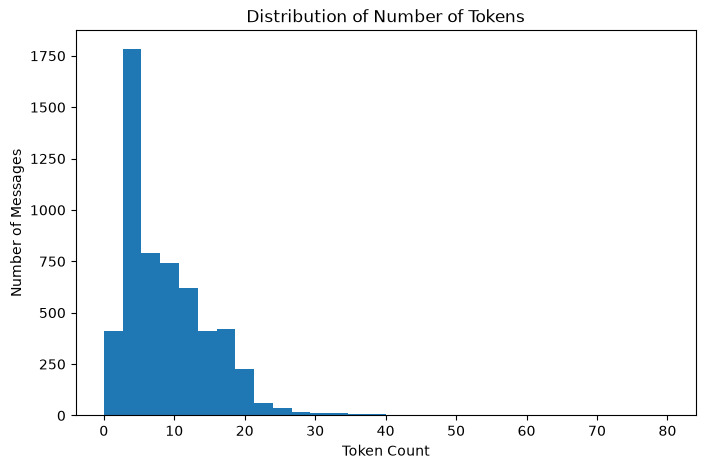

In [60]:
plt.figure(figsize=(8,5))

plt.hist(df["token_count"], bins=30)

plt.title("Distribution of Number of Tokens")
plt.xlabel("Token Count")
plt.ylabel("Number of Messages")

plt.show()

In [59]:
df.sort_values(by='token_count', ascending=False)[["clean_text", "token_count"]].head(10)

,clean_text,token_count
1084,love start attractioni feel need every time ar...,80
1862,last thing ever wanted hurt didnt think would ...,72
2433,indians r poor india poor country says one swi...,70
2369,boy loved gal propsd bt didnt mind gv lv lttrs...,64
5104,boy loved gal propsd bt didnt mind gv lv lttrs...,64
2157,sad story man last week bday wife didnt wish p...,59
2847,sad story man last week bday wife didnt wish p...,59
3015,ltgt fast approaching wish you happy new year ...,57
1578,make girl happy difficult make girls happy you...,55
2064,pass dis your contacts n see what you get redi...,48


## Observations

After applying tokenization, each SMS message was converted into a list of individual words.

From the token count statistics, I observed:

- The average SMS contains approximately **9 words**.
- Half of the messages contain **7 words or fewer** (median = 7).
- Most messages contain between **4 and 13 words**.
- The longest message in the dataset contains **80 words**, which is likely a promotional spam message.

The histogram also shows that the dataset is **right-skewed**. Most SMS messages are short, while only a small number of messages are significantly longer.

Overall, tokenization successfully converted the cleaned text into a format that can now be used for stemming, lemmatization, and other NLP tasks.

In [61]:
df[df['token_count'] == 0][['clean_text', 'token_count']]

,clean_text,token_count
959,,0
1611,,0
2805,,0
3374,,0
4573,,0
4822,,0


### Additional Observation

While exploring the tokenized data, I found that **6 messages became empty after preprocessing**.

After checking these messages, I noticed that they mostly consisted of stopwords or very short filler words. Once punctuation, stopwords, and other unnecessary text were removed, no meaningful words remained.

Since this represents only a very small portion of the dataset (6 out of 5572 messages), it is unlikely to have a significant impact on later preprocessing tasks.

In [66]:
df['sentence_tokenized'] = df['clean_text'].apply(sent_tokenize)
for i in [0, 1, 2]:
    print(f"\nMessage {i+1}:")
    print(df.loc[i, "clean_text"])
    print("\nSentence Tokens:")
    print(df.loc[i, "sentence_tokenized"])


Message 1:
go jurong point crazy available bugis n great world la e buffet cine got amore what

Sentence Tokens:
['go jurong point crazy available bugis n great world la e buffet cine got amore what']

Message 2:
ok lar joking with you oni

Sentence Tokens:
['ok lar joking with you oni']

Message 3:
free entry weekly comp win fa cup final tkts st may text fa receive entry questionstd text ratetcs apply overs

Sentence Tokens:
['free entry weekly comp win fa cup final tkts st may text fa receive entry questionstd text ratetcs apply overs']


In [63]:
df["sentence_count"] = df['sentence_tokenized'].apply(len)
df['sentence_count'].describe()

count    5572.000000
mean        0.998923
std         0.032800
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: sentence_count, dtype: float64

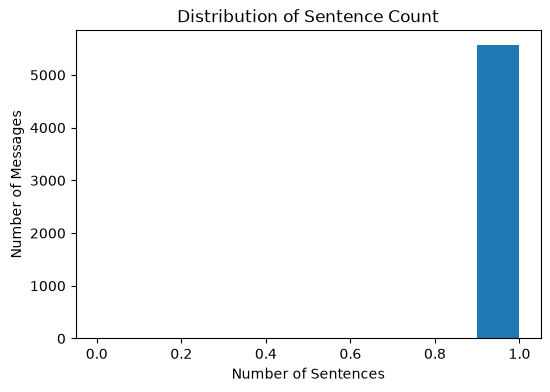

In [64]:
plt.figure(figsize=(6,4))

plt.hist(df["sentence_count"], bins=10)

plt.title("Distribution of Sentence Count")
plt.xlabel("Number of Sentences")
plt.ylabel("Number of Messages")

plt.show()

### Observations

- Nearly every SMS message in this dataset contains only a single sentence.
- A few messages have a sentence count of 0 because they became empty after the preprocessing pipeline removed all valid text.
- SMS datasets generally consist of short messages, so sentence tokenization does not produce multiple sentences very often.
- Word tokenization is more informative for this dataset because most NLP tasks (stemming, lemmatization, stopword removal, etc.) operate at the word level.

## Task-7

In [68]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [69]:
def stem_text(text):
    words = word_tokenize(text)
    stemmed_words = [stemmer.stem(word) for word in words]
    return " ".join(stemmed_words)

In [70]:
df['stemmed_text'] = df['clean_text'].apply(stem_text)

In [72]:
comparison = df[['clean_text', 'stemmed_text']].sample(10)
comparison

,clean_text,stemmed_text
3498,hope arnt pissed id would really like see tomo...,hope arnt piss id would realli like see tomorr...
3750,haha sounds crazy dunno tahan anot,haha sound crazi dunno tahan anot
1080,tell happen dont behave like ok need say,tell happen dont behav like ok need say
4828,long get reply defer admission til next semester,long get repli defer admiss til next semest
786,time fixes spelling sometimes gets completely ...,time fix spell sometim get complet diff word g...
1382,ok arm feeling weak cuz got shot go another time,ok arm feel weak cuz got shot go anoth time
935,dun wear jeans lord,dun wear jean lord
5446,back good journey let know need receipts shall...,back good journey let know need receipt shall ...
3725,chikku nt yet yeah im free,chikku nt yet yeah im free
2033,im gonna miss you much,im gon na miss you much


In [73]:
sample = df.loc[0, "clean_text"]

print("Original:")
print(sample)

print("\nTokenized:")
print(word_tokenize(sample))

print("\nStemmed:")
print([stemmer.stem(word) for word in word_tokenize(sample)])

Original:
go jurong point crazy available bugis n great world la e buffet cine got amore what

Tokenized:
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'what']

Stemmed:
['go', 'jurong', 'point', 'crazi', 'avail', 'bugi', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amor', 'what']


### Observations

- Porter Stemmer reduced several words to their root forms. For example, **crazy → crazi**, **available → avail**, and **amore → amor**.
- Some stemmed words are no longer valid English words. This is expected because stemming simply removes prefixes or suffixes without checking the word's actual meaning.
- Words such as **go**, **point**, **great**, and **world** remained unchanged because they are already close to their root forms.
- From these results, I observed that stemming is useful for reducing vocabulary size, but it can make the processed text less natural and harder to read.

## Task-8

In [74]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [75]:
def lemmatize_text(text):
    words = word_tokenize(text)
    lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(lemmatized_words)

In [76]:
df['lemmatized_text'] = df['clean_text'].apply(lemmatize_text)

In [77]:
comparison = df[['clean_text', 'stemmed_text','lemmatized_text']].sample(8)
comparison

,clean_text,stemmed_text,lemmatized_text
1113,im good movie ok leave hourish,im good movi ok leav hourish,im good movie ok leave hourish
342,you hiding stranger,you hide stranger,you hiding stranger
3279,badrith chennaii surely pick usno competition,badrith chennaii sure pick usno competit,badrith chennaii surely pick usno competition
4367,dont number gonna massive pain ass id rather g...,dont number gon na massiv pain ass id rather g...,dont number gon na massive pain as id rather g...
4772,ok you tell what time you coming later lord,ok you tell what time you come later lord,ok you tell what time you coming later lord
1238,dear relieved westonzoyland going plan end,dear reliev westonzoyland go plan end,dear relieved westonzoyland going plan end
4254,block breaker comes deluxe format new features...,block breaker come delux format new featur gre...,block breaker come deluxe format new feature g...
1572,your cashbalance currently pounds maximize you...,your cashbal current pound maxim your cashin s...,your cashbalance currently pound maximize your...


In [78]:
sample = df.loc[0, "clean_text"]

print("Original:")
print(sample)

print("\nStemmed:")
print(stem_text(sample))

print("\nLemmatized:")
print(lemmatize_text(sample))

Original:
go jurong point crazy available bugis n great world la e buffet cine got amore what

Stemmed:
go jurong point crazi avail bugi n great world la e buffet cine got amor what

Lemmatized:
go jurong point crazy available bugis n great world la e buffet cine got amore what


### Observations

- Lemmatization preserved the readability of the text much better than stemming.
- For example, **movie** remained *movie* after lemmatization, whereas stemming converted it to *movi*. Similarly, **available** remained *available* instead of becoming *avail*.
- I also noticed that lemmatization did not always change every word. For example, **coming** remained *coming* because WordNet assumes it is a noun unless a part-of-speech (POS) tag is provided.
- Overall, stemming is faster but produces shortened words that are sometimes difficult to understand. Lemmatization is slower but generally produces more meaningful and readable words.

## Task-9

In [79]:
def nlp_preprocess(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\S+@\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = remove_repeated_characters(text)
    text = replace_slang(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

In [80]:
df["final_clean_text"] = df["text"].apply(nlp_preprocess)
df[["text", "final_clean_text"]].head()

,text,final_clean_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry weekly comp win fa cup final tkts s...
3,U dun say so early hor... U c already then say...,dun say early hor see already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


In [81]:
empty_messages = (df["final_clean_text"] == "").sum()
print("Messages that became empty after preprocessing:", empty_messages)

Messages that became empty after preprocessing: 10


In [82]:
comparison_df = pd.DataFrame({
    "Original Length": df["text"].str.len(),
    "Processed Length": df["final_clean_text"].str.len()
})

comparison_df.describe()

,Original Length,Processed Length
count,5572.000000,5572.000000
mean,80.118808,49.568198
std,59.690841,37.710118
min,2.000000,0.000000
25%,36.000000,22.000000
50%,61.000000,38.000000
75%,121.000000,73.000000
max,910.000000,513.000000


## Final Observations

After combining all preprocessing steps into a single pipeline, the SMS messages became much cleaner and more consistent.

Some observations from the final output:

- URLs, email addresses, punctuation, and numbers were successfully removed.
- Common SMS abbreviations were replaced with more meaningful words.
- Stopword removal reduced unnecessary words while preserving important information.
- Lemmatization helped keep words readable compared to stemming.
- A few messages became empty after preprocessing because they mainly contained stopwords or very little meaningful text.
- Overall, the preprocessing pipeline significantly reduced noise in the dataset and prepared the text for future NLP tasks such as feature extraction and text classification.

# What I Learned

While completing this assignment, I learned that text preprocessing is not just about cleaning text. Every preprocessing technique changes the dataset in a different way.

For example, I observed that stemming sometimes produces words that are difficult to read, while lemmatization preserves more meaningful English words. I also noticed that removing too many words can occasionally result in empty messages, which is something to consider before training a machine learning model.

Overall, this assignment helped me understand why preprocessing is one of the most important steps in any NLP workflow.